In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# 修正路徑以包含 MyDrive
file_path = '/content/drive/MyDrive/Colab Notebooks/dataset/ParkingRemainDataset.csv'

try:
    df = pd.read_csv(file_path)
    print("成功讀取資料！前五行如下：")
    display(df.head())
except FileNotFoundError:
    print(f"找不到檔案：{file_path}，請確認路徑是否正確。")
except Exception as e:
    print(f"發生錯誤：{e}")

成功讀取資料！前五行如下：


,CollectedAt,IsHoliday,ParkId,TotalSpaces,AvailableSpaces,FullStatus,ParkDataCollectTime,RainNow,RainPast10Min,RainPast1hr,RainPast3hr,RainPast12hr,RainPast24hr
0,2026-05-29T14:23:28,0,1,1998,569,0,2026-05-29T22:21:42+08:00,16.5,0.0,0.0,0.0,1.5,16.5
1,2026-05-29T14:23:28,0,2,446,327,0,2026-05-29T22:21:42+08:00,16.5,0.0,0.0,0.0,1.5,16.5
2,2026-05-29T14:23:28,0,3,169,24,0,2026-05-29T22:21:49+08:00,16.5,0.0,0.0,0.0,1.5,16.5
3,2026-05-29T14:23:28,0,5,204,18,0,2026-05-29T22:21:48+08:00,16.5,0.0,0.0,0.0,1.5,16.5
4,2026-05-29T14:23:28,0,7,508,42,0,2026-05-29T22:21:53+08:00,16.5,0.0,0.0,0.0,1.5,16.5


In [ ]:
# 檢查欄位資訊與資料型態
print("--- 欄位資訊 ---")
df.info()

# 檢查缺失值
print("\n--- 缺失值統計 ---")
print(df.isnull().sum())

--- 欄位資訊 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18080 entries, 0 to 18079
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CollectedAt          18080 non-null  object 
 1   IsHoliday            18080 non-null  int64  
 2   ParkId               18080 non-null  int64  
 3   TotalSpaces          18080 non-null  int64  
 4   AvailableSpaces      18080 non-null  int64  
 5   FullStatus           18080 non-null  int64  
 6   ParkDataCollectTime  18080 non-null  object 
 7   RainNow              18080 non-null  float64
 8   RainPast10Min        18080 non-null  float64
 9   RainPast1hr          18080 non-null  float64
 10  RainPast3hr          18080 non-null  float64
 11  RainPast12hr         18080 non-null  float64
 12  RainPast24hr         18080 non-null  float64
dtypes: float64(6), int64(5), object(2)
memory usage: 1.8+ MB

--- 缺失值統計 ---
CollectedAt            0
IsHoliday              0
P

### 數值描述性統計
我們使用 `describe()` 函式來查看資料集中數值欄位的統計資訊（如平均值、標準差、最大最小值等），這有助於初步觀察資料是否存在異常值或偏態。

In [ ]:
# 顯示數值欄位的統計資訊
display(df.describe())

,IsHoliday,ParkId,TotalSpaces,AvailableSpaces,FullStatus,RainNow,RainPast10Min,RainPast1hr,RainPast3hr,RainPast12hr,RainPast24hr
count,18080.00000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000,18080.000000
mean,0.30000,169.495575,320.886560,75.881803,0.194690,3.781250,0.084375,0.659375,1.778125,5.637500,10.309375
std,0.45827,236.432587,263.977408,113.434368,0.592871,11.749219,0.345615,3.339428,6.920891,14.776122,20.979355
min,0.00000,1.000000,65.000000,-22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,39.000000,186.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,78.000000,251.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.00000,120.000000,359.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000,7.500000
max,1.00000,829.000000,1998.000000,1095.000000,2.000000,58.000000,2.000000,32.500000,48.500000,58.000000,98.000000


### 停車場數量統計
為了了解資料集涵蓋的範圍，我們統計 `ParkId` 欄位中的唯一值數量，確認共有多少個不同的停車場資料被納入分析。

In [ ]:
# 統計不重複的停車場數量
unique_parks = df['ParkId'].nunique()
print(f"資料集中共有 {unique_parks} 個不同的停車場。")

資料集中共有 113 個不同的停車場。


### 各停車場資料筆數檢查
我們透過計算每個 `ParkId` 出現的次數，來確認各個停車場的資料筆數是否相同，這對於後續的分析（如時間序列）的一致性非常重要。

In [ ]:
# 檢查每個停車場的資料筆數
park_counts = df['ParkId'].value_counts()
print("各停車場資料筆數統計：")
display(park_counts)

# 檢查是否所有筆數都相同
if park_counts.nunique() == 1:
    print(f"\n所有停車場的資料筆數皆為 {park_counts.iloc[0]} 筆。")
else:
    print(f"\n警告：各停車場的資料筆數不一致，範圍介於 {park_counts.min()} 到 {park_counts.max()} 之間。")

各停車場資料筆數統計：


,count
ParkId,
1,160
2,160
3,160
5,160
7,160
...,...
768,160
783,160
784,160



所有停車場的資料筆數皆為 160 筆。


### 資料相關性分析
我們計算所有數值欄位之間的 Pearson 相關係數，以了解特徵與目標變數 `AvailableSpaces` 之間的關聯。

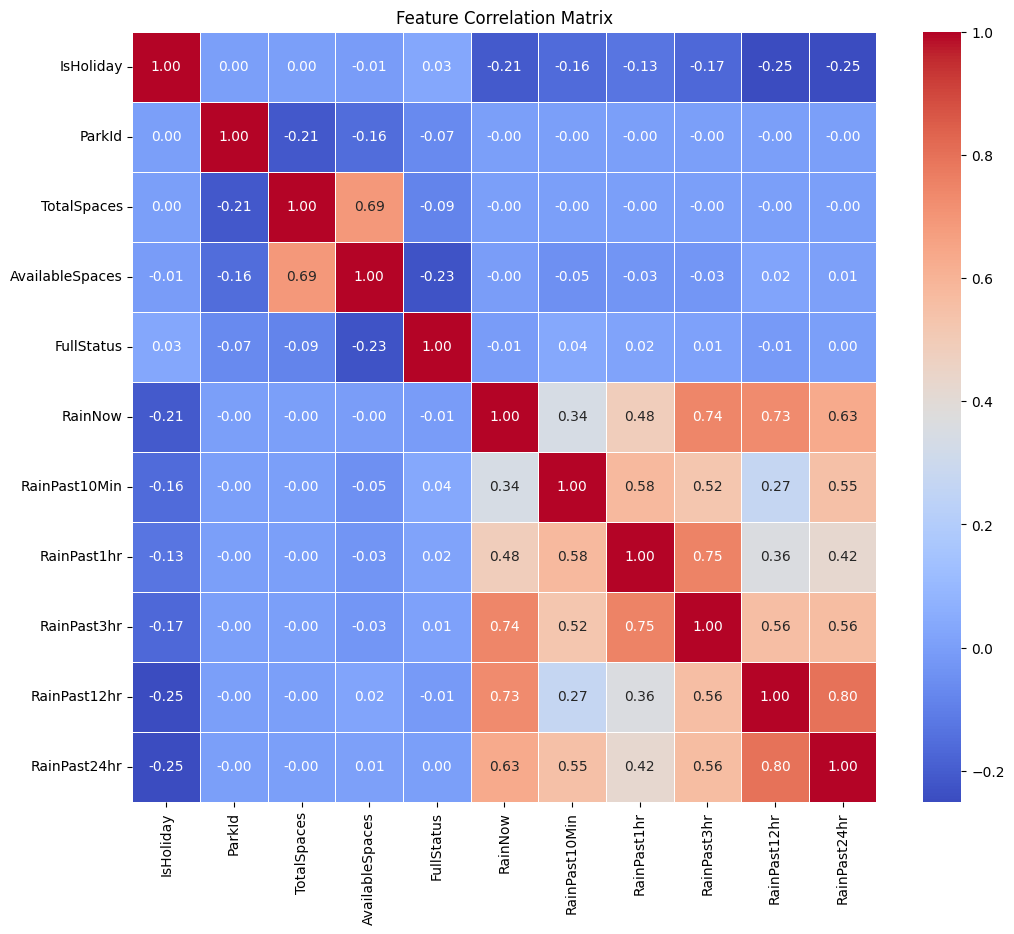

與 AvailableSpaces 的相關性排序：
AvailableSpaces    1.000000
TotalSpaces        0.692151
RainPast12hr       0.021866
RainPast24hr       0.008282
RainNow           -0.003762
IsHoliday         -0.007314
RainPast3hr       -0.030020
RainPast1hr       -0.030897
RainPast10Min     -0.048278
ParkId            -0.155120
FullStatus        -0.225494
Name: AvailableSpaces, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 選擇數值型欄位進行相關性計算
# 排除 CollectedAt (字串) 與原始 ParkDataCollectTime
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# 設定繪圖風格
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# 顯示與 AvailableSpaces 相關性最高的前幾個欄位
print("與 AvailableSpaces 的相關性排序：")
print(corr_matrix['AvailableSpaces'].sort_values(ascending=False))

### 時間特徵工程 (Feature Engineering)
XGBoost 無法直接讀取日期格式。我們需要將 `CollectedAt` 轉換為多個數值欄位（如：小時、星期、月份），這樣模型才能學習到例如「尖峰時段」或「週末與否」對空位影響的規律。

In [ ]:
# 檢查 'ParkDataCollectTime' 欄位是否為原始的 'object' (字串) 類型
# 若是，則進行時間轉換與調整，以確保只執行一次，避免重複累加時差
if pd.api.types.is_object_dtype(df['ParkDataCollectTime']):
    print("Converting 'ParkDataCollectTime' to datetime and applying +8 hour offset...")
    # 將 'ParkDataCollectTime' 轉換為 datetime 格式，並加上 8 小時以校正時區
    # 之後移除時區資訊，使其成為一個本地時間
    df['ParkDataCollectTime'] = pd.to_datetime(df['ParkDataCollectTime']) + pd.Timedelta(hours=8)
    df['ParkDataCollectTime'] = df['ParkDataCollectTime'].dt.tz_localize(None)
elif pd.api.types.is_datetime64_any_dtype(df['ParkDataCollectTime']):
    print("'ParkDataCollectTime' is already datetime type. Skipping +8 hour offset to prevent re-adjustment.")
else:
    print("Warning: 'ParkDataCollectTime' is neither object nor datetime type. No time feature engineering performed for time adjustment.")

# 從調整後（或已調整過）的 'ParkDataCollectTime' 中提取時間特徵
df['Hour'] = df['ParkDataCollectTime'].dt.hour
df['DayOfWeek'] = df['ParkDataCollectTime'].dt.dayofweek
df['Month'] = df['ParkDataCollectTime'].dt.month
df['Day'] = df['ParkDataCollectTime'].dt.day

# 檢查轉換後的新欄位
print("使用修正後（+8小時且移除時區標示）的 ParkDataCollectTime 提取的時間特徵：")
display(df[['ParkDataCollectTime', 'Hour', 'DayOfWeek', 'Month', 'Day']].head())

'ParkDataCollectTime' is already datetime type. Skipping +8 hour offset to prevent re-adjustment.
使用修正後（+8小時且移除時區標示）的 ParkDataCollectTime 提取的時間特徵：


,ParkDataCollectTime,Hour,DayOfWeek,Month,Day
0,2026-05-30 06:21:42,6,5,5,30
1,2026-05-30 06:21:42,6,5,5,30
2,2026-05-30 06:21:49,6,5,5,30
3,2026-05-30 06:21:48,6,5,5,30
4,2026-05-30 06:21:53,6,5,5,30


### 資料清洗：處理可用車位負值
在某些情況下，系統紀錄可能出現負數的可用車位。我們將這些異常值統一修正為 0。

In [ ]:
# 檢查轉換前的負值數量
negative_count = (df['AvailableSpaces'] < 0).sum()
print(f"修正前 AvailableSpaces 中的負值筆數: {negative_count}")

# 將負值轉換為 0
df.loc[df['AvailableSpaces'] < 0, 'AvailableSpaces'] = 0

# 驗證轉換結果
print(f"修正後 AvailableSpaces 中的負值筆數: {(df['AvailableSpaces'] < 0).sum()}")
display(df['AvailableSpaces'].describe())

修正前 AvailableSpaces 中的負值筆數: 166
修正後 AvailableSpaces 中的負值筆數: 0


,AvailableSpaces
count,18080.000000
mean,76.077102
std,113.284562
min,0.000000
25%,15.000000
50%,42.000000
75%,90.000000
max,1095.000000


### XGBoost 模型建立與訓練
將資料依照 8:1:1 的比例切分，並使用 XGBoost 進行迴歸預測。

In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. 定義特徵 (X) 與目標 (y)
features = ['IsHoliday', 'ParkId', 'TotalSpaces', 'RainNow', 'RainPast10Min',
            'RainPast1hr', 'RainPast3hr', 'RainPast12hr', 'RainPast24hr',
            'Hour', 'DayOfWeek', 'Month', 'Day']
target = 'AvailableSpaces'

X = df[features]
y = df[target]

# 2. 資料集切割 (80% 訓練, 10% 驗證, 10% 測試)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"訓練集大小: {X_train.shape}")
print(f"驗證集大小: {X_val.shape}")
print(f"測試集大小: {X_test.shape}")

# 3. 建立並訓練模型
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# 4. 預測與評估
y_pred = model.predict(X_test)
# 確保預測值也不會有負數
y_pred = np.maximum(y_pred, 0)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n測試集 RMSE: {rmse:.2f}")
print(f"測試集 R2 Score: {r2:.4f}")

# 顯示部分預測結果對照
results = pd.DataFrame({'實際值': y_test, '預測值': y_pred.astype(int)}).reset_index(drop=True)
display(results.head(10))

訓練集大小: (14464, 13)
驗證集大小: (1808, 13)
測試集大小: (1808, 13)
[0]	validation_0-rmse:114.88832
[100]	validation_0-rmse:30.69372
[200]	validation_0-rmse:23.35041
[300]	validation_0-rmse:20.56135
[400]	validation_0-rmse:18.89887
[500]	validation_0-rmse:18.00072
[600]	validation_0-rmse:17.32008
[700]	validation_0-rmse:16.86123
[800]	validation_0-rmse:16.48028
[900]	validation_0-rmse:16.20265
[999]	validation_0-rmse:16.03337

測試集 RMSE: 13.84
測試集 R2 Score: 0.9829


,實際值,預測值
0,50,38
1,0,0
2,84,98
3,35,28
4,0,4
5,0,3
6,46,40
7,325,340
8,431,416
9,394,389


### 視覺化特徵重要性
透過特徵重要性圖表，我們可以觀察哪些變數（如總車位數、時間、雨量等）對模型預測剩餘車位數的貢獻最大。

<Figure size 1000x800 with 0 Axes>

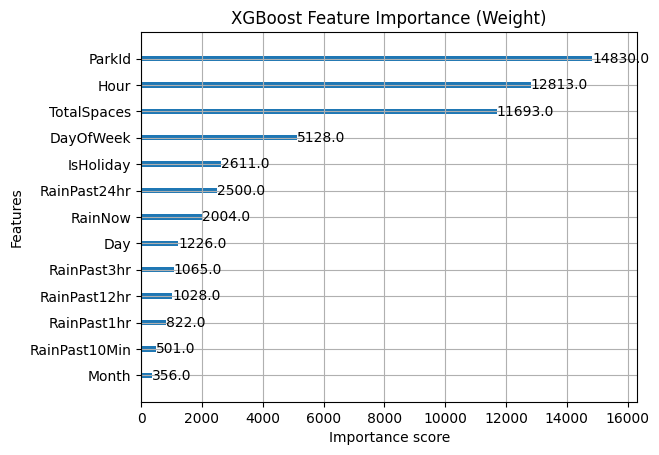

In [ ]:
import matplotlib.pyplot as plt

# 繪製特徵重要性
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='weight', max_num_features=15)
plt.title('XGBoost Feature Importance (Weight)')
plt.show()